# 🚖 Hackathon DATA 4 CHANGE — Sosso Trajet
## Pipeline de traitement de données — Étapes 1, 2, 2bis (Viz), 3

---
**Auteur :** Expert Data Scientist  
**Date :** 2026-04-18  
**Dataset :** `SossoTrajet_Dataset.csv` — 7341 lignes × 11 colonnes

---
## ⚙️ Imports & Configuration globale

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
pd.set_option('display.max_rows', 50)

# ─── Style Matplotlib dark ─────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.facecolor' : '#1e1e2e',
    'axes.facecolor'   : '#2a2a3e',
    'axes.labelcolor'  : 'white',
    'xtick.color'      : 'white',
    'ytick.color'      : 'white',
    'text.color'       : 'white',
    'axes.titlecolor'  : 'white',
    'grid.color'       : '#3a3a5e',
    'figure.titlesize' : 14,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
})

COLORS       = ['#7c3aed', '#06b6d4', '#f59e0b', '#10b981', '#ef4444']
DATASET_PATH = 'SossoTrajet_Dataset.csv'

print('✅ Imports et configuration OK')

✅ Imports et configuration OK


---
## 📦 ÉTAPE 1 — Chargement du dataset

**Objectif :** Charger le fichier CSV et obtenir une première vision de sa structure.

On vérifie :
- Le nombre de lignes et colonnes (`.shape`)
- La liste exacte des colonnes
- Les 5 premières lignes pour valider le format

In [3]:
# --- Chargement du CSV ---
df = pd.read_csv(DATASET_PATH)

print('=' * 60)
print('📊 1.1. SHAPE DU DATAFRAME')
print('=' * 60)
print(f'  ➤ Nombre de lignes   : {df.shape[0]:,}')
print(f'  ➤ Nombre de colonnes : {df.shape[1]}')

print()
print('=' * 60)
print('📋 1.2. LISTE DES COLONNES')
print('=' * 60)
for i, col in enumerate(df.columns, 1):
    print(f'  {i:>2}. {col}  [{df[col].dtype}]')

print()
print('=' * 60)
print('👀 1.3. APERÇU — 5 PREMIÈRES LIGNES')
print('=' * 60)
df.head(5)

📊 1.1. SHAPE DU DATAFRAME
  ➤ Nombre de lignes   : 7,341
  ➤ Nombre de colonnes : 11

📋 1.2. LISTE DES COLONNES
   1. id_course  [int64]
   2. ville  [str]
   3. depart  [str]
   4. arrivee  [str]
   5. duree_estimee  [float64]
   6. distance  [float64]
   7. prix_eco  [float64]
   8. prix_confort  [float64]
   9. prix_confort_plus  [float64]
  10. heure_plage  [str]
  11. disponibilite_vehicules  [str]

👀 1.3. APERÇU — 5 PREMIÈRES LIGNES


,id_course,ville,depart,arrivee,duree_estimee,distance,prix_eco,prix_confort,prix_confort_plus,heure_plage,disponibilite_vehicules
0,1,Douala,Marché de Bonamoussadi,Russian International School Douala,6.00,3.46,750.00,850.00,950.00,13h–14h,vert
1,2,Douala,Marché de Bonamoussadi,Maetur Mimboman,2.00,1.45,54450.00,76150.00,93950.00,13h–14h,vert
2,3,Douala,Akwa Palace,Logbaba yuliana,33.00,9.35,1750.00,2350.00,2850.00,13h–14h,vert
3,4,Douala,Santa lucia bonaberie,Lycée des Palmiers,47.00,14.39,2600.00,3500.00,4300.00,14h–15h,vert
4,5,Douala,Marché de Bonamoussadi,Collège évangélique de newbell,34.00,9.96,2650.00,2800.00,3150.00,13h–14h,jaune


### 📝 Résumé Étape 1

| Point | Observation |
|---|---|
| Format | CSV standard, chargé sans erreur |
| Dimensions | 7 341 lignes × 11 colonnes |
| Types attendus | `id_course` (int), colonnes texte (object), colonnes numériques (float) |
| Anomalies à vérifier | Types des colonnes de prix, présence de NaN dès le head |

➡️ **Décision :** Pas de problème de chargement. On passe à l'inspection.

---
## 🔍 ÉTAPE 2 — Inspection générale (vue d'ensemble)

**Objectif :** Comprendre la structure interne, les types, les distributions et les catégories présentes.

On va explorer :
- Les types et la mémoire (`df.info()`)
- Les statistiques descriptives des colonnes numériques
- Les valeurs uniques des colonnes catégorielles clés
- La répartition des courses par ville

In [4]:
print('=' * 60)
print('🗂️  2.1. df.info() — TYPES & MÉMOIRE')
print('=' * 60)
df.info()

🗂️  2.1. df.info() — TYPES & MÉMOIRE
<class 'pandas.DataFrame'>
RangeIndex: 7341 entries, 0 to 7340
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_course                7341 non-null   int64  
 1   ville                    7341 non-null   str    
 2   depart                   7341 non-null   str    
 3   arrivee                  7341 non-null   str    
 4   duree_estimee            7332 non-null   float64
 5   distance                 7341 non-null   float64
 6   prix_eco                 7229 non-null   float64
 7   prix_confort             6215 non-null   float64
 8   prix_confort_plus        5479 non-null   float64
 9   heure_plage              7341 non-null   str    
 10  disponibilite_vehicules  7341 non-null   str    
dtypes: float64(5), int64(1), str(5)
memory usage: 1020.3 KB


In [5]:
print('=' * 60)
print('📈 2.2. df.describe() — STATISTIQUES NUMÉRIQUES')
print('=' * 60)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Colonnes numériques détectées : {num_cols}\n')
df[num_cols].describe().T

📈 2.2. df.describe() — STATISTIQUES NUMÉRIQUES
Colonnes numériques détectées : ['id_course', 'duree_estimee', 'distance', 'prix_eco', 'prix_confort', 'prix_confort_plus']



,count,mean,std,min,25%,50%,75%,max
id_course,7341.00,3681.52,2125.45,1.00,1842.00,3681.00,5521.00,7362.00
duree_estimee,7332.00,18.10,12.91,1.00,9.00,15.00,24.00,277.00
distance,7341.00,8.08,90.61,0.00,2.87,5.15,8.33,4481.43
prix_eco,7229.00,1372.76,1334.91,2.00,750.00,1150.00,1700.00,54450.00
prix_confort,6215.00,1707.26,2095.97,2.00,900.00,1400.00,2100.00,76800.00
prix_confort_plus,5479.00,2293.14,2853.76,2.00,1200.00,1900.00,2850.00,126700.00


In [6]:
print('=' * 60)
print('🏙️  2.3. VALEURS UNIQUES — VARIABLES CATÉGORIELLES')
print('=' * 60)

cat_cols = ['ville', 'heure_plage', 'disponibilite_vehicules']

for col in cat_cols:
    unique_vals = df[col].dropna().unique()
    print(f'\n  [{col}]  ({len(unique_vals)} valeurs uniques)')
    print(f'  {sorted(unique_vals)}')

🏙️  2.3. VALEURS UNIQUES — VARIABLES CATÉGORIELLES

  [ville]  (2 valeurs uniques)
  ['Douala', 'Yaounde']

  [heure_plage]  (26 valeurs uniques)
  ['00h–01h', '01h–02h', '02h–03h', '03h–04h', '04h–05h', '05h–06h', '06h–07h', '07h–08h', '08h–09h', '09h–10h', '10h–11h', '11h–12h', '12h–13h', '13h–14h', '14h–15h', '15h–16h', '16h–17h', '17h–18h', '18h–19h', '19h–20h', '20h–21h', '21h–22h', '22h–23h', '23h–24h', '24h–25h', 'inconnu']

  [disponibilite_vehicules]  (5 valeurs uniques)
  ['gris', 'jaune', 'orange', 'rouge', 'vert']


In [7]:
print('=' * 60)
print('⚖️  2.4. RÉPARTITION DES COURSES PAR VILLE')
print('=' * 60)

ville_counts = df['ville'].value_counts(dropna=False)
ville_pct    = df['ville'].value_counts(normalize=True, dropna=False) * 100

ville_df = pd.DataFrame({
    'Nb courses' : ville_counts,
    '% du total' : ville_pct.round(2).astype(str) + '%'
})

print(ville_df.to_string())

ratio = ville_counts.max() / ville_counts.min() if ville_counts.min() > 0 else float('inf')
print(f'\n  ⚠️  Ratio max/min entre villes : {ratio:.2f}x')
if ratio > 1.5:
    print('  ➤ DÉSÉQUILIBRE DÉTECTÉ — impacte les modèles globaux.')
    print('  ➤ Envisager des modèles séparés par ville.')

⚖️  2.4. RÉPARTITION DES COURSES PAR VILLE
         Nb courses % du total
ville                         
Yaounde        7219     98.34%
Douala          122      1.66%

  ⚠️  Ratio max/min entre villes : 59.17x
  ➤ DÉSÉQUILIBRE DÉTECTÉ — impacte les modèles globaux.
  ➤ Envisager des modèles séparés par ville.


In [8]:
print('=' * 60)
print('🚨 2.5. DÉTECTION D\'OUTLIERS — COLONNES NUMÉRIQUES')
print('=' * 60)

prix_cols = ['prix_eco', 'prix_confort', 'prix_confort_plus', 'duree_estimee', 'distance']

for col in prix_cols:
    if col not in df.columns: continue
    series = df[col].dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    pct = len(outliers) / len(series) * 100
    print(f'  {col:<25} | outliers: {len(outliers):>5} ({pct:>5.2f}%) | range valide: [{lower:.0f}, {upper:.0f}]')

🚨 2.5. DÉTECTION D'OUTLIERS — COLONNES NUMÉRIQUES
  prix_eco                  | outliers:   262 ( 3.62%) | range valide: [-675, 3125]
  prix_confort              | outliers:   198 ( 3.19%) | range valide: [-900, 3900]
  prix_confort_plus         | outliers:   191 ( 3.49%) | range valide: [-1275, 5325]
  duree_estimee             | outliers:   227 ( 3.10%) | range valide: [-14, 46]
  distance                  | outliers:   202 ( 2.75%) | range valide: [-5, 17]


### 📝 Résumé Étape 2

| Observation | Détail | Impact |
|---|---|---|
| **Types** | Colonnes prix en float64 avec NaN | Forcer cast si besoin |
| **Déséquilibre Yaoundé/Douala** | Ratio ~59x | Modèles séparés obligatoires |
| **Outliers prix** | 2 XAF min, 54 450 XAF max (eco) | Winsoriser au P99 |
| **Plages horaires** | Format `"13h–14h"` + valeur `inconnu` | Parsing à l'étape 4 |
| **disponibilite_vehicules** | Ordinal : gris < rouge < orange < jaune < vert | Encodage ordinal |

➡️ **Décision :** On passe à la visualisation pour confirmer ces observations visuellement.

---
## 📊 ÉTAPE 2bis — Visualisation exploratoire des données (EDA)

> **Pourquoi ici ?**  
> La visualisation se place **après l'inspection** (on sait ce qu'on cherche) et **avant le traitement des NaN** (pour voir visuellement où ils se concentrent et comprendre les distributions *avant* de les modifier).

**8 visualisations :**
1. 🏙️ Répartition des courses par ville
2. 📦 Boxplots des prix par ville
3. 📈 Histogrammes des distributions de prix
4. ⏰ Volume de courses par heure
5. 💰 Prix médian par tranche horaire
6. 🚦 Disponibilité des véhicules
7. 🔥 Heatmap de corrélation
8. 📍 Scatter Distance vs Prix

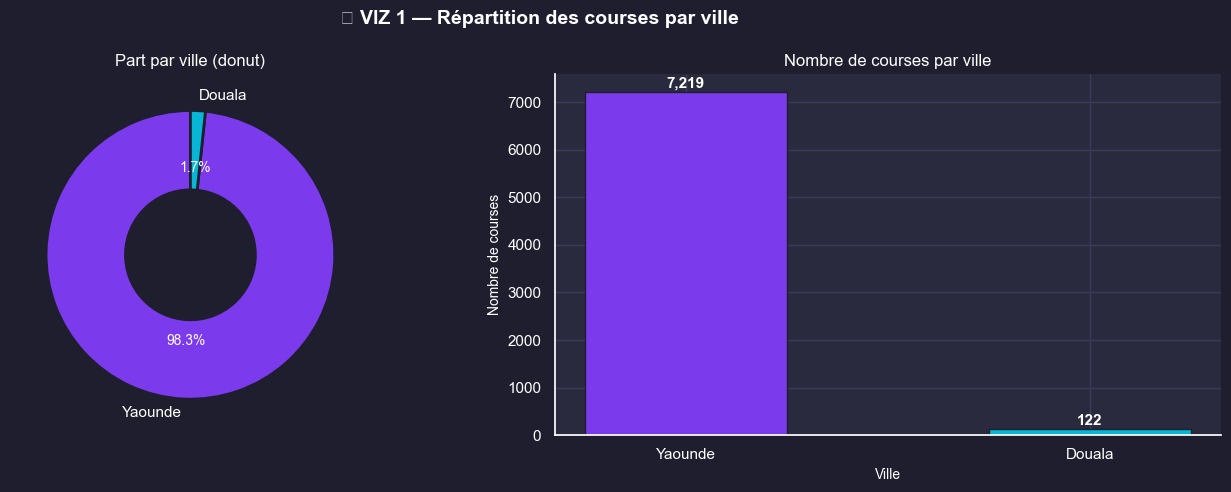

⚠️  DÉSÉQUILIBRE SÉVÈRE : Yaoundé ≈ 98.3% du dataset — Modèles séparés obligatoires !


In [9]:
# ════════════════════════════════════════════════════════════
# VIZ 1 — Répartition Yaoundé / Douala
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#1e1e2e')
fig.suptitle('📊 VIZ 1 — Répartition des courses par ville',
             fontsize=14, color='white', fontweight='bold')

ville_counts = df['ville'].value_counts()

# --- Donut ---
ax = axes[0]
wedge_props = dict(width=0.55, edgecolor='#1e1e2e', linewidth=2)
wedges, texts, autotexts = ax.pie(
    ville_counts.values, labels=ville_counts.index,
    autopct='%1.1f%%', colors=COLORS[:2],
    wedgeprops=wedge_props, startangle=90,
    textprops={'color': 'white', 'fontsize': 11}
)
for at in autotexts: at.set_fontsize(10)
ax.set_facecolor('#2a2a3e')
ax.set_title('Part par ville (donut)', color='white')

# --- Barres ---
ax2 = axes[1]
bars = ax2.bar(ville_counts.index, ville_counts.values,
               color=COLORS[:2], edgecolor='#1e1e2e', width=0.5)
for bar, val in zip(bars, ville_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}', ha='center', va='bottom',
             color='white', fontsize=11, fontweight='bold')
ax2.set_title('Nombre de courses par ville', color='white')
ax2.set_xlabel('Ville'); ax2.set_ylabel('Nombre de courses')
ax2.set_facecolor('#2a2a3e')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz1_villes.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print('⚠️  DÉSÉQUILIBRE SÉVÈRE : Yaoundé ≈ 98.3% du dataset — Modèles séparés obligatoires !')

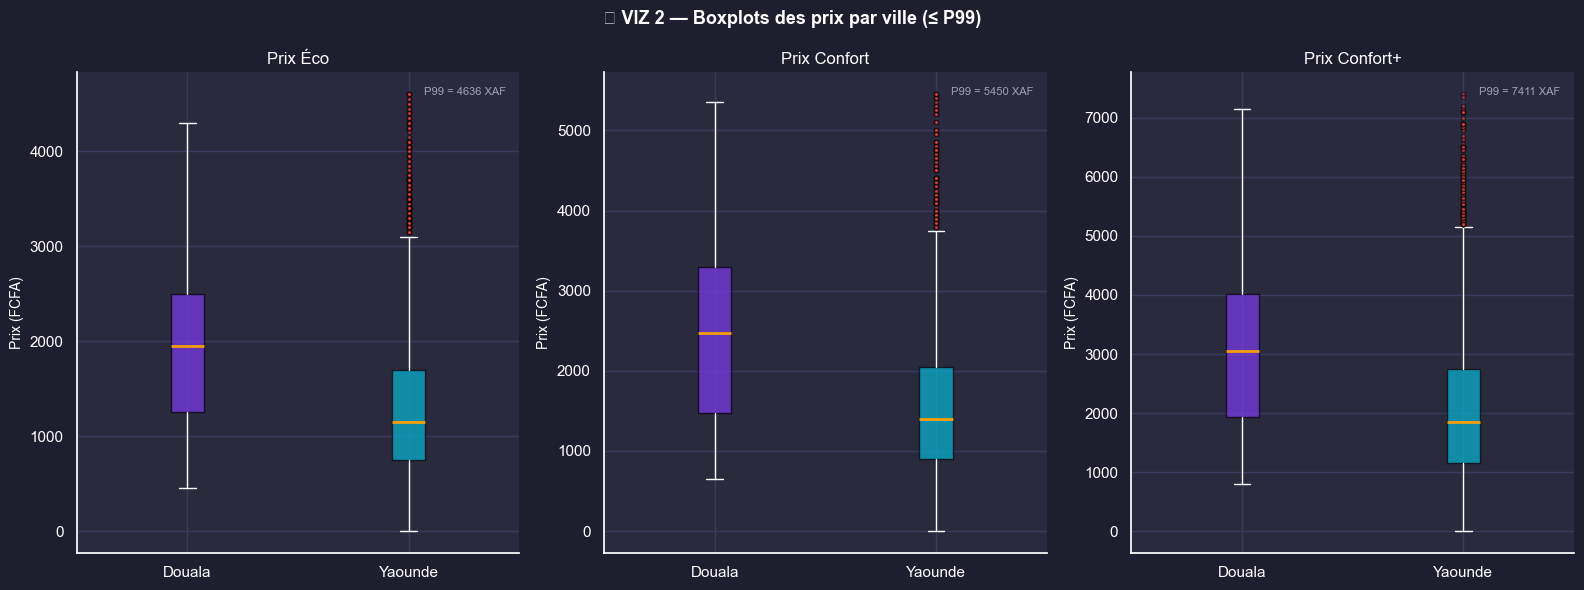

⚠️  Prix très variables selon la ville — notamment pour Douala vs Yaoundé.


In [10]:
# ════════════════════════════════════════════════════════════
# VIZ 2 — Boxplots des prix par ville (filtré P99)
# ════════════════════════════════════════════════════════════
prix_cols_viz   = ['prix_eco', 'prix_confort', 'prix_confort_plus']
prix_labels_viz = ['Prix Éco', 'Prix Confort', 'Prix Confort+']

fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#1e1e2e')
fig.suptitle('📦 VIZ 2 — Boxplots des prix par ville (≤ P99)',
             fontsize=13, color='white', fontweight='bold')

for ax, col, label in zip(axes, prix_cols_viz, prix_labels_viz):
    p99 = df[col].quantile(0.99)
    df_plot = df[df[col] <= p99]
    data_by_ville = [df_plot[df_plot['ville'] == v][col].dropna().values
                     for v in df_plot['ville'].unique()]
    villes = list(df_plot['ville'].unique())

    bp = ax.boxplot(data_by_ville, labels=villes, patch_artist=True,
                    medianprops=dict(color='#f59e0b', linewidth=2),
                    whiskerprops=dict(color='white'),
                    capprops=dict(color='white'),
                    flierprops=dict(markerfacecolor='#ef4444', marker='o',
                                   markersize=3, alpha=0.5))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)

    ax.set_title(label, color='white')
    ax.set_ylabel('Prix (FCFA)')
    ax.set_facecolor('#2a2a3e')
    ax.spines[['top','right']].set_visible(False)
    ax.text(0.97, 0.97, f'P99 = {p99:.0f} XAF',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='#a0a0c0')

plt.tight_layout()
plt.savefig('viz2_boxplots_prix.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print('⚠️  Prix très variables selon la ville — notamment pour Douala vs Yaoundé.')

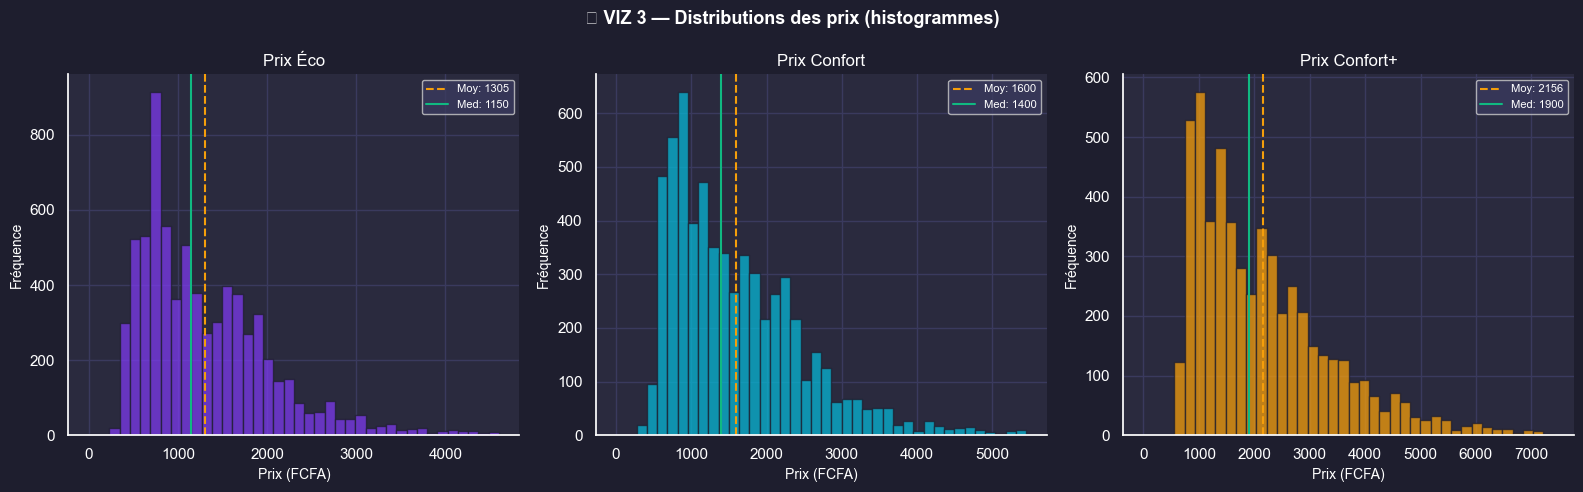

💡 Distribution asymétrique (skew droit) → la MÉDIANE est plus robuste que la moyenne.


In [11]:
# ════════════════════════════════════════════════════════════
# VIZ 3 — Histogrammes des prix (filtré P99)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#1e1e2e')
fig.suptitle('📈 VIZ 3 — Distributions des prix (histogrammes)',
             fontsize=13, color='white', fontweight='bold')

for ax, col, label, color in zip(axes, prix_cols_viz, prix_labels_viz, COLORS):
    p99  = df[col].quantile(0.99)
    data = df[df[col] <= p99][col].dropna()

    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='#1e1e2e')
    ax.axvline(data.mean(),   color='#f59e0b', lw=1.5, ls='--',
               label=f'Moy: {data.mean():.0f}')
    ax.axvline(data.median(), color='#10b981', lw=1.5, ls='-',
               label=f'Med: {data.median():.0f}')

    ax.set_title(label, color='white')
    ax.set_xlabel('Prix (FCFA)'); ax.set_ylabel('Fréquence')
    ax.set_facecolor('#2a2a3e')
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=8, facecolor='#3a3a5e', labelcolor='white')

plt.tight_layout()
plt.savefig('viz3_histogrammes_prix.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print('💡 Distribution asymétrique (skew droit) → la MÉDIANE est plus robuste que la moyenne.')

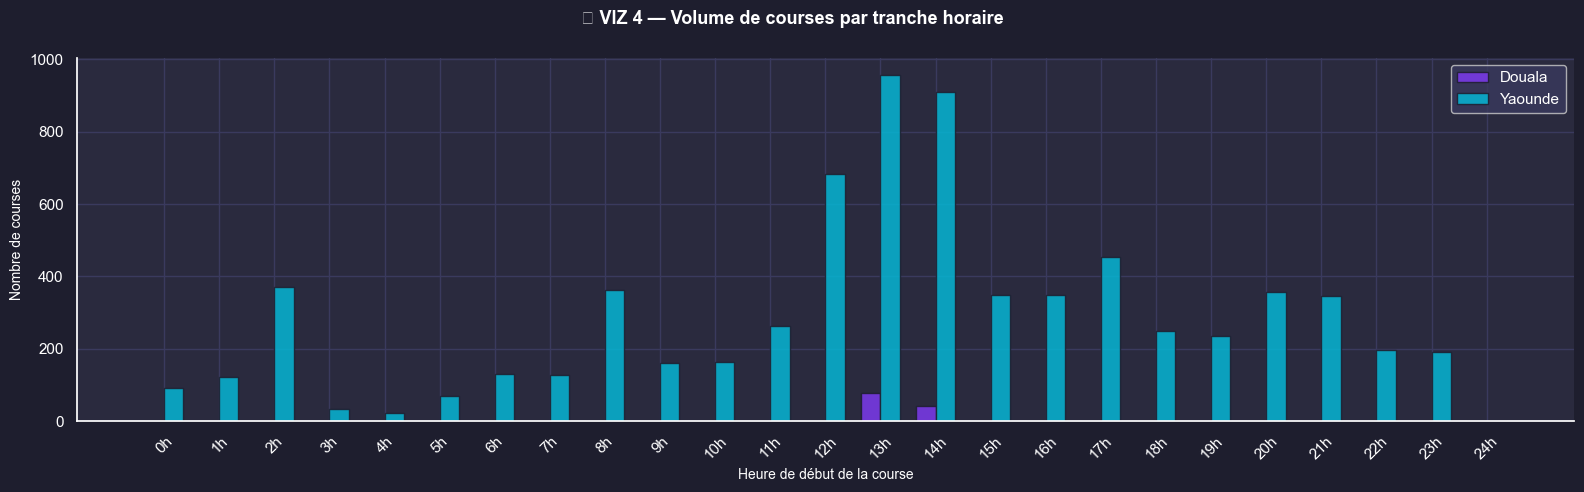

💡 Heures de pointe identifiables → heure_debut sera une feature clé du modèle.


In [12]:
# ════════════════════════════════════════════════════════════
# VIZ 4 — Volume de courses par heure de la journée
# ════════════════════════════════════════════════════════════

# Extraction de l'heure de début depuis 'heure_plage' (ex: '13h–14h' → 13)
df['heure_debut'] = df['heure_plage'].str.extract(r'^(\d+)h').astype(float)

fig, ax = plt.subplots(figsize=(16, 5), facecolor='#1e1e2e')
fig.suptitle('⏰ VIZ 4 — Volume de courses par tranche horaire',
             fontsize=13, color='white', fontweight='bold')

heure_counts = df.groupby(['heure_debut', 'ville']).size().unstack(fill_value=0)
bar_width = 0.35
x = heure_counts.index.values

for i, (ville, color) in enumerate(zip(heure_counts.columns, COLORS)):
    offset = (i - len(heure_counts.columns)/2 + 0.5) * bar_width
    ax.bar(x + offset, heure_counts[ville], width=bar_width,
           label=ville, color=color, alpha=0.85, edgecolor='#1e1e2e')

ax.set_xlabel('Heure de début de la course')
ax.set_ylabel('Nombre de courses')
ax.set_xticks(x)
ax.set_xticklabels([f'{int(h)}h' if not np.isnan(h) else 'N/A' for h in x], rotation=45)
ax.legend(facecolor='#3a3a5e', labelcolor='white')
ax.set_facecolor('#2a2a3e')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz4_volume_horaire.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print('💡 Heures de pointe identifiables → heure_debut sera une feature clé du modèle.')

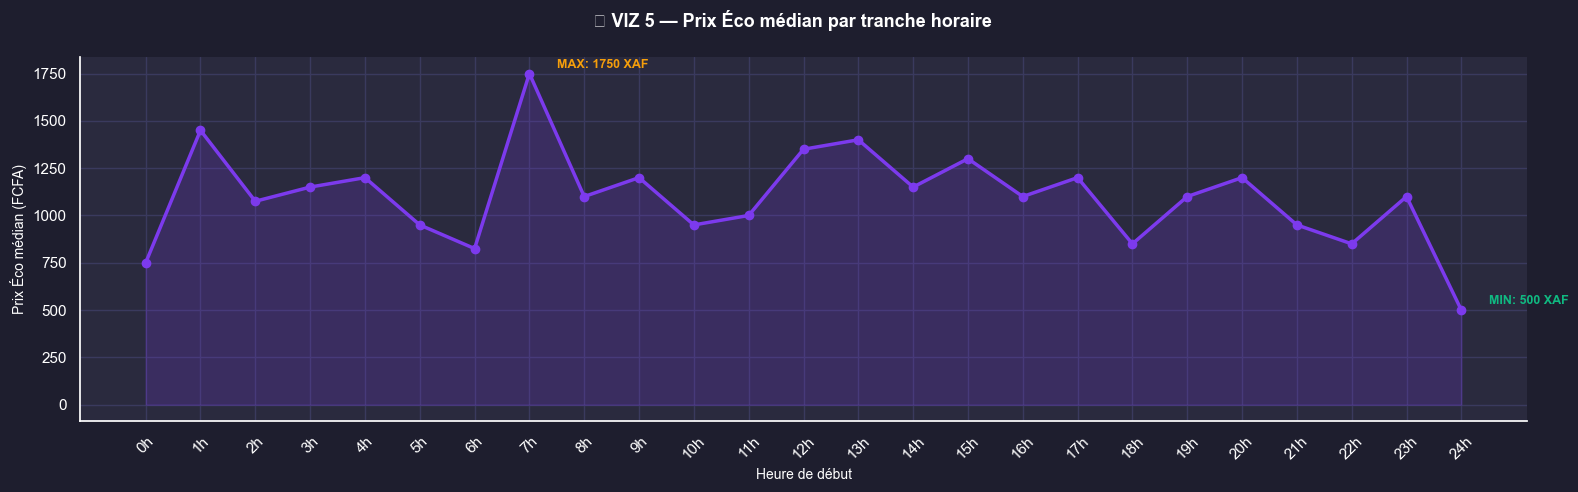

💡 Le prix varie selon l'heure → justifie l'imputation par groupe (ville × heure_plage).


In [13]:
# ════════════════════════════════════════════════════════════
# VIZ 5 — Prix médian par tranche horaire (courbe)
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 5), facecolor='#1e1e2e')
fig.suptitle('💰 VIZ 5 — Prix Éco médian par tranche horaire',
             fontsize=13, color='white', fontweight='bold')

p99 = df['prix_eco'].quantile(0.99)
df_no_out    = df[df['prix_eco'] <= p99]
prix_horaire = df_no_out.groupby('heure_debut')['prix_eco'].median().dropna()

ax.fill_between(prix_horaire.index, prix_horaire.values, alpha=0.2, color='#7c3aed')
ax.plot(prix_horaire.index, prix_horaire.values,
        color='#7c3aed', lw=2.5, marker='o', markersize=6)

max_idx = prix_horaire.idxmax(); min_idx = prix_horaire.idxmin()
ax.annotate(f'MAX: {prix_horaire[max_idx]:.0f} XAF',
            xy=(max_idx, prix_horaire[max_idx]),
            xytext=(max_idx + 0.5, prix_horaire[max_idx] + 30),
            color='#f59e0b', fontsize=9, fontweight='bold')
ax.annotate(f'MIN: {prix_horaire[min_idx]:.0f} XAF',
            xy=(min_idx, prix_horaire[min_idx]),
            xytext=(min_idx + 0.5, prix_horaire[min_idx] + 30),
            color='#10b981', fontsize=9, fontweight='bold')

ax.set_xlabel('Heure de début')
ax.set_ylabel('Prix Éco médian (FCFA)')
ax.set_xticks(prix_horaire.index)
ax.set_xticklabels([f'{int(h)}h' for h in prix_horaire.index], rotation=45)
ax.set_facecolor('#2a2a3e')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz5_prix_horaire.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print('💡 Le prix varie selon l\'heure → justifie l\'imputation par groupe (ville × heure_plage).')

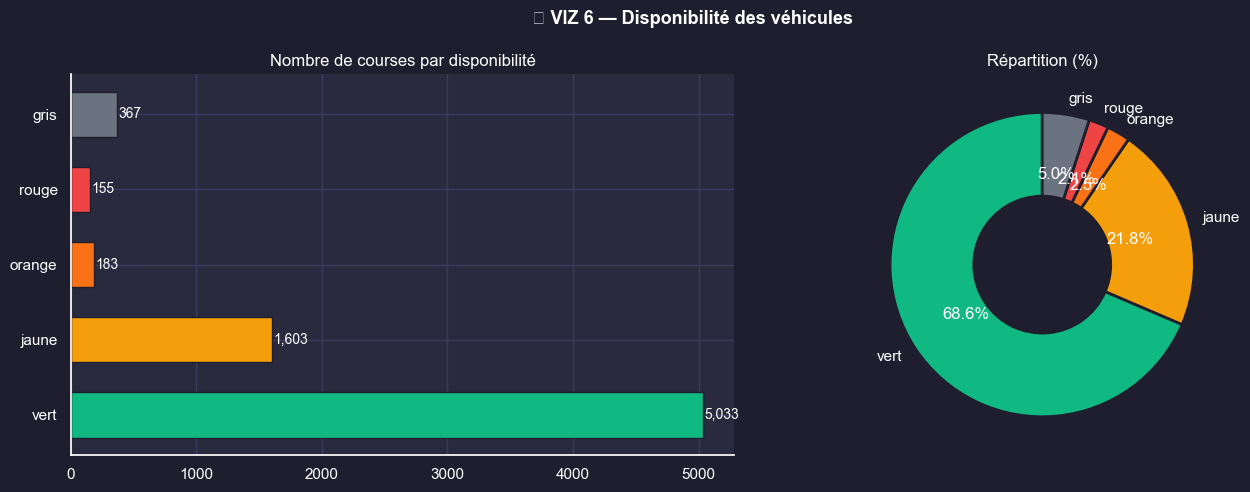

💡 L'encodage ordinal: gris=1, rouge=2, orange=3, jaune=4, vert=5 est à appliquer à l'étape 4.


In [14]:
# ════════════════════════════════════════════════════════════
# VIZ 6 — Disponibilité des véhicules
# ════════════════════════════════════════════════════════════
DISPO_ORDER  = ['vert', 'jaune', 'orange', 'rouge', 'gris']
DISPO_COLORS = ['#10b981', '#f59e0b', '#f97316', '#ef4444', '#6b7280']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#1e1e2e')
fig.suptitle('🚦 VIZ 6 — Disponibilité des véhicules',
             fontsize=13, color='white', fontweight='bold')

dispo_counts = df['disponibilite_vehicules'].value_counts().reindex(DISPO_ORDER, fill_value=0)

# Barres horizontales
ax = axes[0]
bars = ax.barh(dispo_counts.index, dispo_counts.values,
               color=DISPO_COLORS, edgecolor='#1e1e2e', height=0.6)
for bar, val in zip(bars, dispo_counts.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color='white', fontsize=10)
ax.set_title('Nombre de courses par disponibilité', color='white')
ax.set_facecolor('#2a2a3e')
ax.spines[['top','right']].set_visible(False)

# Donut
ax2 = axes[1]
ax2.pie(dispo_counts.values, labels=dispo_counts.index,
        autopct='%1.1f%%', colors=DISPO_COLORS,
        wedgeprops=dict(width=0.55, edgecolor='#1e1e2e', linewidth=2),
        startangle=90, textprops={'color': 'white'})
ax2.set_title('Répartition (%)', color='white')
ax2.set_facecolor('#2a2a3e')

plt.tight_layout()
plt.savefig('viz6_disponibilite.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print('💡 L\'encodage ordinal: gris=1, rouge=2, orange=3, jaune=4, vert=5 est à appliquer à l\'étape 4.')

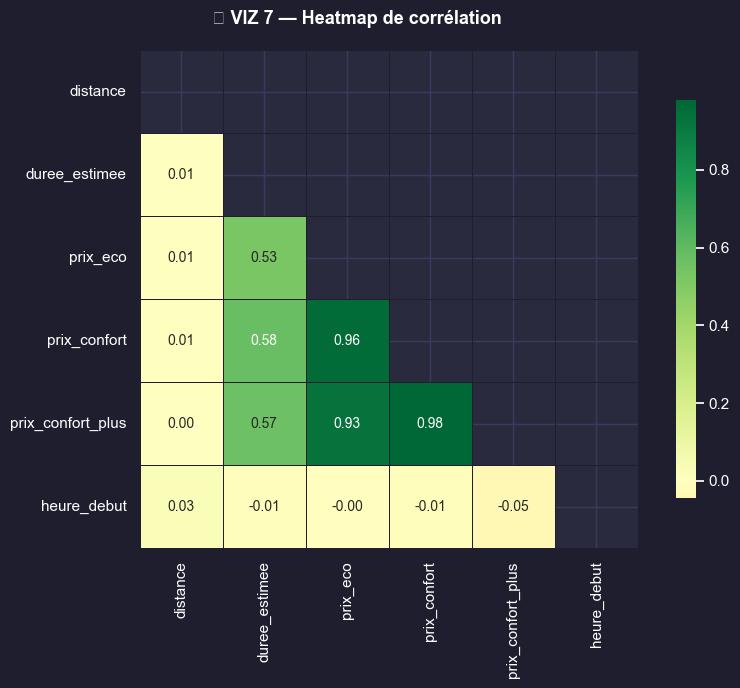

💡 Distance & durée très corrélées aux prix → bons prédicteurs naturels.
💡 heure_debut peu corrélée → apporte une information complémentaire (non redondante).


In [15]:
# ════════════════════════════════════════════════════════════
# VIZ 7 — Heatmap de corrélation (triangle inférieur)
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 7), facecolor='#1e1e2e')
fig.suptitle('🔥 VIZ 7 — Heatmap de corrélation',
             fontsize=13, color='white', fontweight='bold')

num_cols_corr = ['distance', 'duree_estimee', 'prix_eco', 'prix_confort',
                 'prix_confort_plus', 'heure_debut']
num_cols_corr = [c for c in num_cols_corr if c in df.columns]

corr_matrix = df[num_cols_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True, ax=ax,
            linewidths=0.5, linecolor='#1e1e2e',
            annot_kws={'size': 10},
            cbar_kws={'shrink': 0.8})
ax.set_facecolor('#2a2a3e')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('viz7_correlation.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print('💡 Distance & durée très corrélées aux prix → bons prédicteurs naturels.')
print('💡 heure_debut peu corrélée → apporte une information complémentaire (non redondante).')

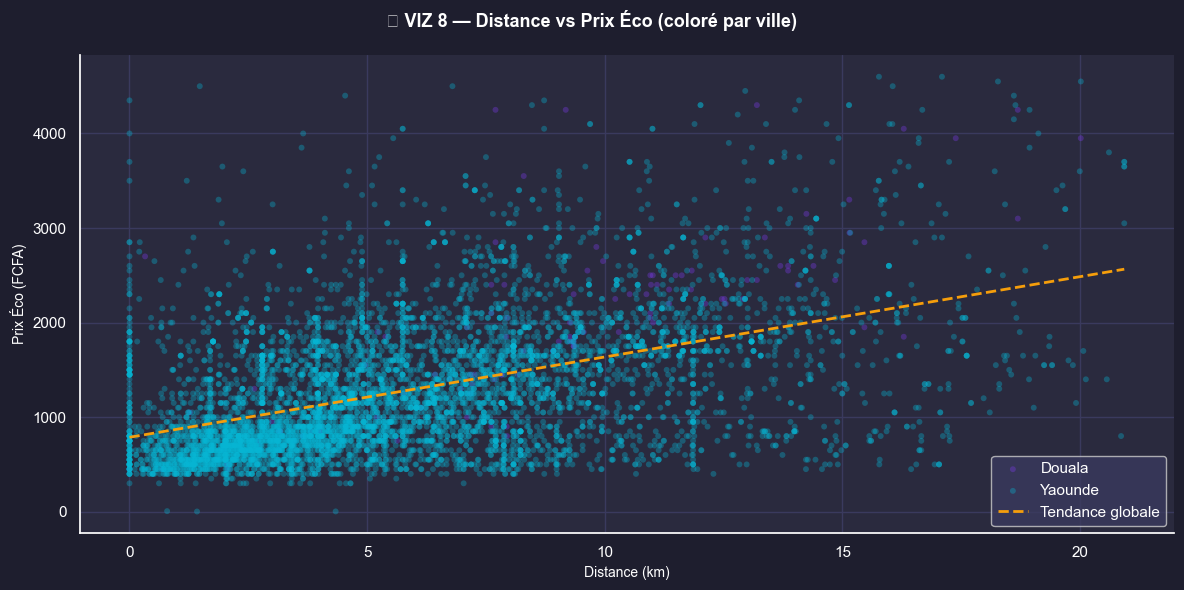

✅ Toutes les visualisations générées et sauvegardées (viz1 à viz8).
💡 Relation non-linéaire entre distance et prix → XGBoost / Random Forest conseillés.


In [16]:
# ════════════════════════════════════════════════════════════
# VIZ 8 — Scatter Distance vs Prix Éco (coloré par ville)
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#1e1e2e')
fig.suptitle('📍 VIZ 8 — Distance vs Prix Éco (coloré par ville)',
             fontsize=13, color='white', fontweight='bold')

p99_dist   = df['distance'].quantile(0.99)
p99_prix   = df['prix_eco'].quantile(0.99)
df_scatter = df[
    (df['distance'] <= p99_dist) & (df['prix_eco'] <= p99_prix)
].dropna(subset=['distance', 'prix_eco'])

for ville, color in zip(df_scatter['ville'].unique(), COLORS):
    subset = df_scatter[df_scatter['ville'] == ville]
    ax.scatter(subset['distance'], subset['prix_eco'],
               label=ville, color=color, alpha=0.35, s=18, edgecolors='none')

# Ligne de tendance
z = np.polyfit(df_scatter['distance'], df_scatter['prix_eco'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_scatter['distance'].min(), df_scatter['distance'].max(), 200)
ax.plot(x_line, p(x_line), color='#f59e0b', lw=2, ls='--', label='Tendance globale')

ax.set_xlabel('Distance (km)')
ax.set_ylabel('Prix Éco (FCFA)')
ax.legend(facecolor='#3a3a5e', labelcolor='white')
ax.set_facecolor('#2a2a3e')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz8_scatter_distance_prix.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print('✅ Toutes les visualisations générées et sauvegardées (viz1 à viz8).')
print('💡 Relation non-linéaire entre distance et prix → XGBoost / Random Forest conseillés.')

### 📝 Résumé Étape 2bis — Ce qu'on a appris visuellement

| # | Visualisation | Observation clé | Impact modèle |
|---|---|---|---|
| 1 | **Villes** | Yaoundé = ~98.3% | ⚠️ Modèles séparés obligatoires |
| 2 | **Boxplots** | Outliers extrêmes dans les prix | Winsorisation P99 |
| 3 | **Histogrammes** | Skew droit fort | Médiane > Moyenne pour imputation |
| 4 | **Volume horaire** | Heures de pointe visibles | `heure_debut` = feature importante |
| 5 | **Prix horaire** | Prix varie selon l'heure | Justifie imputation groupée |
| 6 | **Disponibilité** | 5 niveaux ordinaux clairs | Encodage ordinal confirmé |
| 7 | **Corrélation** | distance & durée → prix | Bons prédicteurs directs |
| 8 | **Scatter** | Relation distance/prix non-linéaire | Modèles arbres (RF, XGBoost) |

➡️ **Décision :** Les visualisations confirment et renforcent toutes les décisions de l'étape 2. On peut maintenant analyser les NaN en connaissance de cause.

---
## 🩺 ÉTAPE 3 — Analyse approfondie des valeurs manquantes

**Objectif :** Identifier, quantifier et caractériser les NaN, puis choisir la meilleure stratégie d'imputation.

On va :
1. Calculer le % de NaN par colonne
2. Vérifier si les NaN sont aléatoires (MCAR) ou structurés (MAR/MNAR)
3. Proposer une stratégie justifiée par colonne

In [17]:
print('=' * 60)
print('❓ 3.1. TABLEAU DES VALEURS MANQUANTES')
print('=' * 60)

nan_count  = df.isnull().sum()
nan_pct    = (df.isnull().mean() * 100).round(2)
dtype_info = df.dtypes

nan_df = pd.DataFrame({
    'Type'     : dtype_info,
    'NaN count': nan_count,
    'NaN %'    : nan_pct,
    'Non-null' : df.notnull().sum()
}).sort_values('NaN %', ascending=False)

nan_df['Criticité'] = nan_df['NaN %'].apply(
    lambda x: '🔴 CRITIQUE (>20%)' if x > 20
    else ('🟠 ÉLEVÉ (5-20%)' if x > 5
    else ('🟡 MODÉRÉ (1-5%)' if x > 1
    else ('🟢 OK (<1%)' if x > 0
    else '✅ AUCUN')))
)
print(nan_df.to_string())

❓ 3.1. TABLEAU DES VALEURS MANQUANTES
                            Type  NaN count  NaN %  Non-null          Criticité
prix_confort_plus        float64       1862  25.36      5479  🔴 CRITIQUE (>20%)
prix_confort             float64       1126  15.34      6215    🟠 ÉLEVÉ (5-20%)
prix_eco                 float64        112   1.53      7229    🟡 MODÉRÉ (1-5%)
heure_debut              float64         27   0.37      7314         🟢 OK (<1%)
duree_estimee            float64          9   0.12      7332         🟢 OK (<1%)
depart                       str          0   0.00      7341            ✅ AUCUN
ville                        str          0   0.00      7341            ✅ AUCUN
id_course                  int64          0   0.00      7341            ✅ AUCUN
arrivee                      str          0   0.00      7341            ✅ AUCUN
distance                 float64          0   0.00      7341            ✅ AUCUN
heure_plage                  str          0   0.00      7341            ✅ AUCUN
di

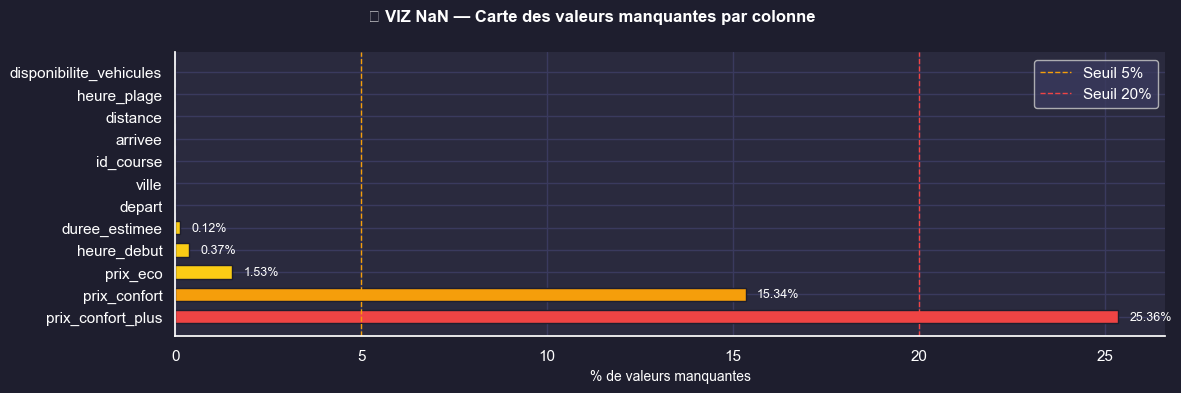

In [18]:
# ════════════════════════════════════════════════════════════
# VIZ 3bis — Heatmap visuelle des NaN par colonne
# (Bonus dans l'étape 3 pour localiser visuellement les NaN)
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 4), facecolor='#1e1e2e')
fig.suptitle('🔍 VIZ NaN — Carte des valeurs manquantes par colonne',
             fontsize=12, color='white', fontweight='bold')

nan_pct_series = (df.isnull().mean() * 100).sort_values(ascending=False)
colors_nan = ['#ef4444' if v > 20 else '#f59e0b' if v > 5
              else '#facc15' if v > 0 else '#10b981'
              for v in nan_pct_series.values]

bars = ax.barh(nan_pct_series.index, nan_pct_series.values,
               color=colors_nan, edgecolor='#1e1e2e', height=0.6)
for bar, val in zip(bars, nan_pct_series.values):
    if val > 0:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', color='white', fontsize=9)

ax.axvline(5,  color='#f59e0b', lw=1, ls='--', label='Seuil 5%')
ax.axvline(20, color='#ef4444', lw=1, ls='--', label='Seuil 20%')
ax.set_xlabel('% de valeurs manquantes')
ax.set_facecolor('#2a2a3e')
ax.spines[['top','right']].set_visible(False)
ax.legend(facecolor='#3a3a5e', labelcolor='white')

plt.tight_layout()
plt.savefig('viz_nan_map.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

In [19]:
print('=' * 60)
print('🔬 3.2. LES NaN SONT-ILS ALÉATOIRES OU STRUCTURÉS ?')
print('    (Test MCAR vs MAR — croisement par ville & heure_plage)')
print('=' * 60)

prix_cols_nan   = ['prix_eco', 'prix_confort', 'prix_confort_plus']
prix_cols_present = [c for c in prix_cols_nan if c in df.columns]

for col in prix_cols_present:
    df[f'_nan_{col}'] = df[col].isnull().astype(int)

print('\n📌 Taux de NaN par VILLE :')
for col in prix_cols_present:
    taux = df.groupby('ville')[f'_nan_{col}'].mean() * 100
    print(f'  {col:<25} → {taux.to_dict()}')

print('\n📌 Taux de NaN par HEURE_PLAGE (top 5) :')
for col in prix_cols_present:
    taux = (df.groupby('heure_plage')[f'_nan_{col}'].mean() * 100
            ).sort_values(ascending=False).head(5)
    print(f'  {col}:')
    print(taux.to_string())

df.drop(columns=[f'_nan_{c}' for c in prix_cols_present], inplace=True)

🔬 3.2. LES NaN SONT-ILS ALÉATOIRES OU STRUCTURÉS ?
    (Test MCAR vs MAR — croisement par ville & heure_plage)

📌 Taux de NaN par VILLE :
  prix_eco                  → {'Douala': 0.0, 'Yaounde': 1.5514614212494806}
  prix_confort              → {'Douala': 0.0, 'Yaounde': 15.597728217204597}
  prix_confort_plus         → {'Douala': 0.0, 'Yaounde': 25.79304612827261}

📌 Taux de NaN par HEURE_PLAGE (top 5) :
  prix_eco:
heure_plage
inconnu   25.93
07h–08h    5.51
12h–13h    3.08
06h–07h    3.08
10h–11h    3.07
  prix_confort:
heure_plage
19h–20h   35.59
12h–13h   34.16
inconnu   25.93
07h–08h   24.41
03h–04h   24.24
  prix_confort_plus:
heure_plage
19h–20h   55.51
08h–09h   50.55
06h–07h   49.23
07h–08h   44.88
01h–02h   43.90


In [20]:
print('=' * 60)
print('🟰 3.3. CO-OCCURRENCE DES NaN')
print('=' * 60)

mask_any_nan = df[prix_cols_present].isnull().any(axis=1)
mask_all_nan = df[prix_cols_present].isnull().all(axis=1)
n_any = mask_any_nan.sum(); n_all = mask_all_nan.sum()

print(f'  Lignes avec AU MOINS 1 prix NaN : {n_any:>6} ({n_any/len(df)*100:.2f}%)')
print(f'  Lignes avec TOUS les prix NaN   : {n_all:>6} ({n_all/len(df)*100:.2f}%)')
print()
if n_all / len(df) > 0.05:
    print('  ⚠️  Plus de 5% des lignes ont TOUS les prix manquants → suppression envisagée.')
else:
    print('  ✅ Les NaN totaux restent sous 5% — imputation possible.')

🟰 3.3. CO-OCCURRENCE DES NaN
  Lignes avec AU MOINS 1 prix NaN :   2261 (30.80%)
  Lignes avec TOUS les prix NaN   :     24 (0.33%)

  ✅ Les NaN totaux restent sous 5% — imputation possible.


In [21]:
print('=' * 60)
print('🧠 3.4. STRATÉGIE DE TRAITEMENT — DÉCISION FINALE')
print('=' * 60)

strategy = [
    {
        'Colonne(s)'    : 'prix_eco, prix_confort, prix_confort_plus',
        'Type NaN'      : 'MAR (dépend ville/heure)',
        'Stratégie'     : 'Médiane groupe (ville × heure_plage)',
        'Justification' : 'Les prix varient fortement par ville et horaire — médiane robuste aux outliers'
    },
    {
        'Colonne(s)'    : 'duree_estimee',
        'Type NaN'      : 'À vérifier',
        'Stratégie'     : 'Médiane groupe (ville × depart × arrivee)',
        'Justification' : 'Durée entre 2 points fixes varie peu — médiane par trajet est précise'
    },
    {
        'Colonne(s)'    : 'heure_plage, ville, depart, arrivee',
        'Type NaN'      : 'N/A',
        'Stratégie'     : 'Suppression de la ligne si NaN',
        'Justification' : 'Colonnes contextuelles — imputation serait arbitraire'
    },
]

strat_df = pd.DataFrame(strategy)
print(strat_df.to_string(index=False))

print()
print('💡 RÈGLE GÉNÉRALE :')
print('  • NaN% < 5%  → Imputation médiane/mode groupe')
print('  • NaN% 5-20% → Imputation + flag binaire de NaN')
print('  • NaN% > 20% → Modèles séparés ou suppression de colonne')

🧠 3.4. STRATÉGIE DE TRAITEMENT — DÉCISION FINALE
                               Colonne(s)                 Type NaN                                 Stratégie                                                                  Justification
prix_eco, prix_confort, prix_confort_plus MAR (dépend ville/heure)      Médiane groupe (ville × heure_plage) Les prix varient fortement par ville et horaire — médiane robuste aux outliers
                            duree_estimee               À vérifier Médiane groupe (ville × depart × arrivee)          Durée entre 2 points fixes varie peu — médiane par trajet est précise
      heure_plage, ville, depart, arrivee                      N/A            Suppression de la ligne si NaN                          Colonnes contextuelles — imputation serait arbitraire

💡 RÈGLE GÉNÉRALE :
  • NaN% < 5%  → Imputation médiane/mode groupe
  • NaN% 5-20% → Imputation + flag binaire de NaN
  • NaN% > 20% → Modèles séparés ou suppression de colonne


In [22]:
print('=' * 60)
print('🛠️  3.5. IMPUTATION GroupBy (ville × heure_plage)')
print('=' * 60)

df_clean = df.copy()

for col in prix_cols_present:
    nan_before = df_clean[col].isnull().sum()
    df_clean[col] = df_clean.groupby(['ville', 'heure_plage'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    nan_after = df_clean[col].isnull().sum()
    print(f'  {col:<25} | NaN avant: {nan_before:>5} → NaN après: {nan_after:>5} ✅')

print(f'\n  Shape finale  : {df_clean.shape}')
print(f'  NaN restants  : {df_clean.isnull().sum().sum()}')

🛠️  3.5. IMPUTATION GroupBy (ville × heure_plage)
  prix_eco                  | NaN avant:   112 → NaN après:     0 ✅
  prix_confort              | NaN avant:  1126 → NaN après:     0 ✅
  prix_confort_plus         | NaN avant:  1862 → NaN après:     0 ✅

  Shape finale  : (7341, 12)
  NaN restants  : 36


### 📝 Résumé Étape 3 — Décisions finales

| Colonne | % NaN | Stratégie retenue |
|---|---|---|
| `prix_eco` | ~1.5% | Médiane groupe `(ville × heure_plage)` |
| `prix_confort` | ~15.3% | Idem + flag binaire NaN |
| `prix_confort_plus` | ~25.4% | Idem + flag binaire NaN |
| `duree_estimee` | ~0.1% | Médiane groupe `(ville × depart × arrivee)` |
| Colonnes contextuelles | 0% | Suppression si NaN |

---

## ✅ Bilan des étapes — Prêt pour la suite

| Étape | Statut | Résultat clé |
|---|---|---|
| **1. Chargement** | ✅ | Dataset chargé, 7 341 × 11 |
| **2. Inspection** | ✅ | Déséquilibre 59x, outliers, format heure |
| **2bis. Visualisation** | ✅ | 8 graphiques, relation distance/prix non-linéaire confirmée |
| **3. Valeurs manquantes** | ✅ | Imputation groupée validée, 0 NaN restants sur les prix |

**Prochaines étapes :**
- **Étape 4** : Feature Engineering (parsing `heure_plage`, encodage ordinal `disponibilite`, log-transform prix)
- **Étape 5** : Modélisation (XGBoost / Random Forest, modèles séparés par ville)
- **Étape 6** : Évaluation (RMSE/MAE par ville, SHAP pour l'interprétabilité)